# Data MC agreement
## Plot phase space variables and make sure data and MC agree well

### Turn off statistics box

In [1]:
gStyle->SetOptStat(0);

### Path with $KK\pi\pi$ single tag selection

In [2]:
std::string SelectionPath("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/Selection/");
SelectionPath += "WithDeltaECuts/DoubleTag/Kpipi0/";

### Load data

In [3]:
TChain DataChain("Kpipi0DoubleTag");
DataChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_Data*.root").c_str());

### Load inclusive MC

In [4]:
TChain MCChain("Kpipi0DoubleTag");
MCChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_D0D0*.root").c_str());
MCChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_D+D-*.root").c_str());
MCChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_ditau*.root").c_str());
MCChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_nonDD*.root").c_str());
MCChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_qq*.root").c_str());
MCChain.Add((SelectionPath + "KKpipiDoubleTags_WithDeltaECuts_RR*.root").c_str());

### $K^+K^-$ invariant mass histograms

In [5]:
TH1D s01_Data("s01_Data", "", 50, 0.987354*0.987354, 1.58569922*1.58569922);
TH1D s01_MC("s01_MC", "", 50, 0.987354*0.987354, 1.58569922*1.58569922);

In [6]:
std::string s01Formula = "(SignalKPlusenergy + SignalKMinusenergy)^2";
s01Formula += "- (SignalKPluspx + SignalKMinuspx)^2";
s01Formula += "- (SignalKPluspy + SignalKMinuspy)^2";
s01Formula += "- (SignalKPluspz + SignalKMinuspz)^2";
std::string CutFormula = "SignalMBC > 1.86 && SignalMBC < 1.87";
CutFormula += " && TagMBC > 1.86 && TagMBC < 1.87";

In [7]:
DataChain.Draw((s01Formula + " >> s01_Data").c_str(), CutFormula.c_str(), "GOFF");
MCChain.Draw((s01Formula + " >> s01_MC").c_str(), CutFormula.c_str(), "GOFF");
s01_MC.Scale(0.1);

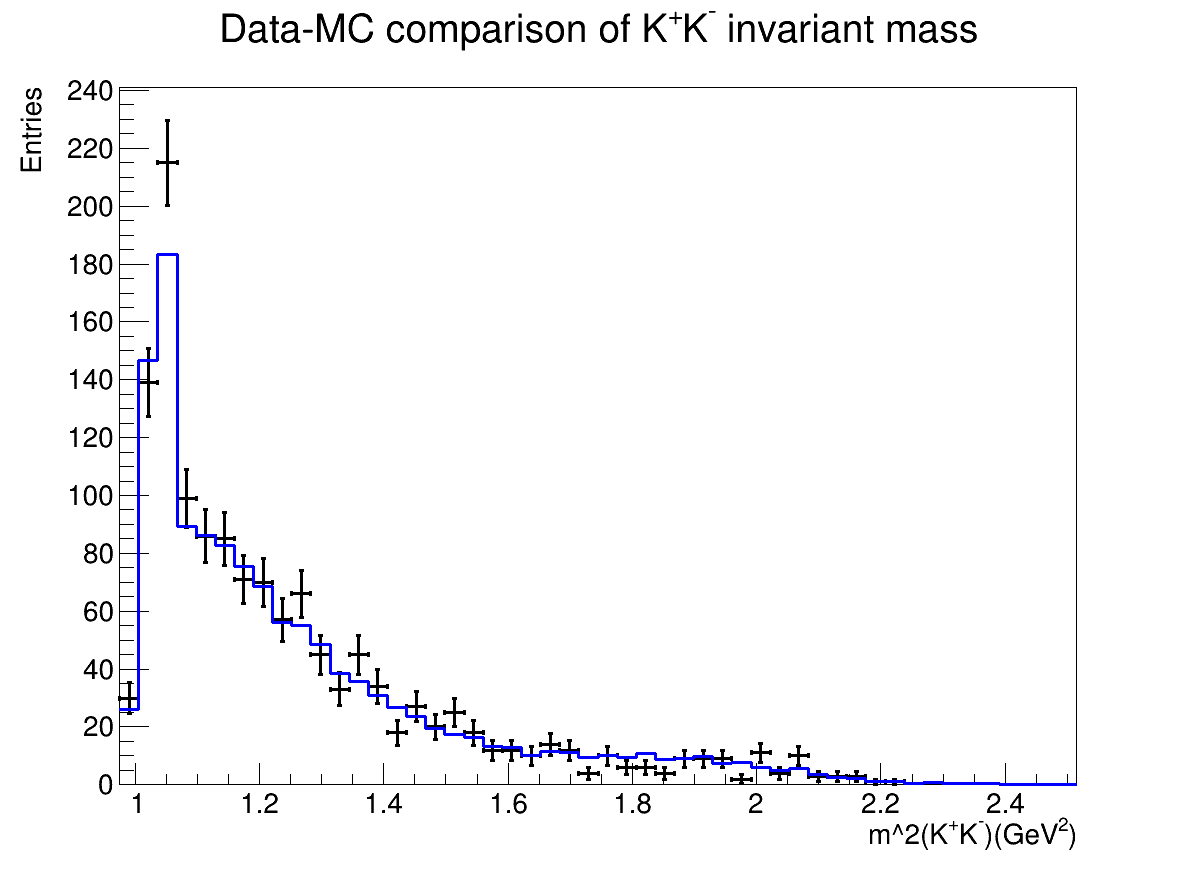

Info in <TCanvas::Print>: pdf file Data_MC_comparison_s01.pdf has been created


In [8]:
TCanvas s01_c("s01_c", "", 1200, 900);
s01_Data.Draw("E1");
s01_Data.SetTitle("Data-MC comparison of K^{+}K^{-} invariant mass;m^2(K^{+}K^{-})(GeV^{2});Entries");
s01_Data.SetLineColor(kBlack);
s01_Data.SetLineWidth(3);
s01_MC.Draw("HIST SAME");
s01_MC.SetLineColor(kBlue);
s01_MC.SetLineWidth(3);
s01_c.Draw();
s01_c.SaveAs("Data_MC_comparison_s01.pdf");

### $K^+\pi^-$ invariant mass histograms

In [9]:
TH1D s03_Data("s03_Data", "", 50, 0.63324739*0.63324739, 1.23159261*1.23159261);
TH1D s03_MC("s03_MC", "", 50, 0.63324739*0.63324739, 1.23159261*1.23159261);

In [10]:
std::string s03Formula = "(SignalKPlusenergy + SignalPiMinusenergy)^2";
s03Formula += "- (SignalKPluspx + SignalPiMinuspx)^2";
s03Formula += "- (SignalKPluspy + SignalPiMinuspy)^2";
s03Formula += "- (SignalKPluspz + SignalPiMinuspz)^2";

In [11]:
std::string s12Formula = "(SignalKMinusenergy + SignalPiPlusenergy)^2";
s12Formula += "- (SignalKMinuspx + SignalPiPluspx)^2";
s12Formula += "- (SignalKMinuspy + SignalPiPluspy)^2";
s12Formula += "- (SignalKMinuspz + SignalPiPluspz)^2";

In [12]:
std::string s03Formula_flavour = "(" + s03Formula + ")*(TagKCharge == -1)";
s03Formula_flavour += " + (" + s12Formula + ")*(TagKCharge == +1)";

In [13]:
DataChain.Draw((s03Formula_flavour + " >> s03_Data").c_str(), CutFormula.c_str(), "GOFF");
MCChain.Draw((s03Formula_flavour + " >> s03_MC").c_str(), CutFormula.c_str(), "GOFF");
s03_MC.Scale(0.1);

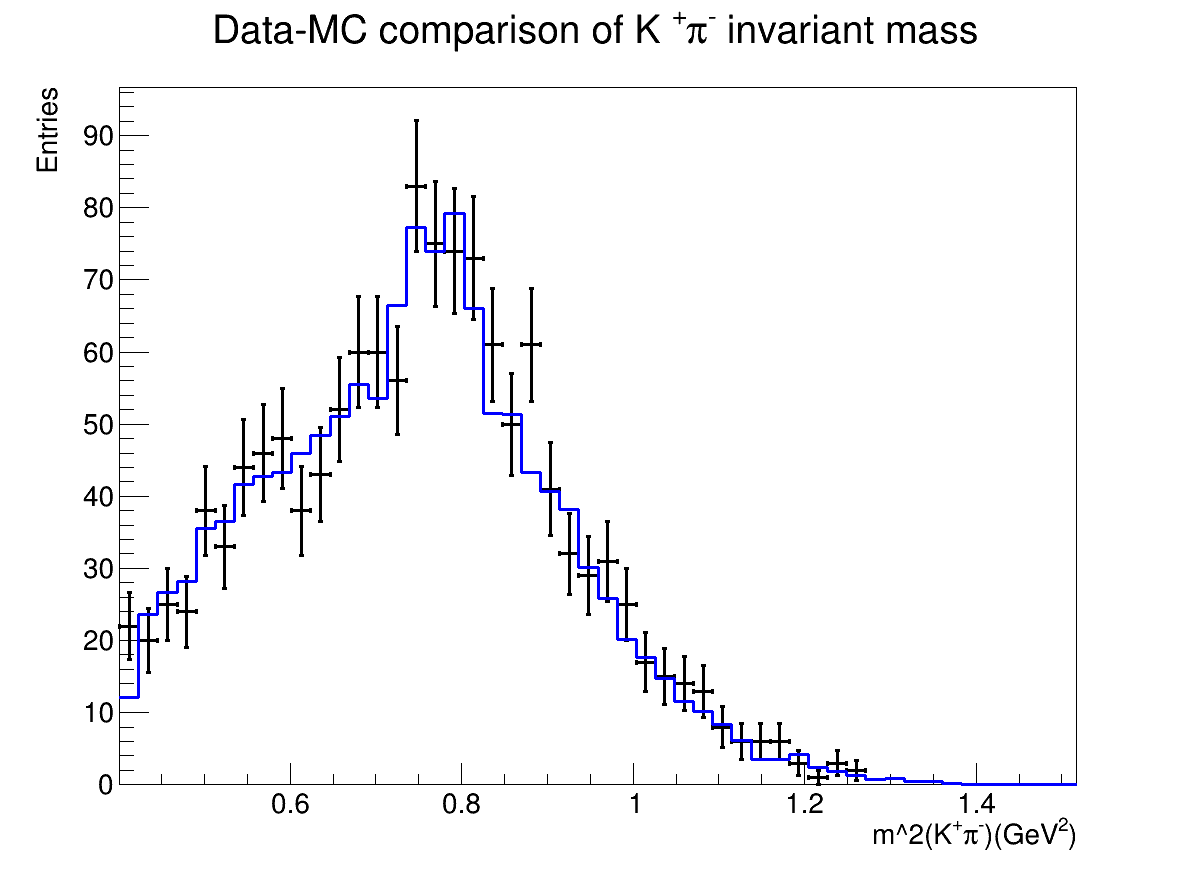

Info in <TCanvas::Print>: pdf file Data_MC_comparison_s03.pdf has been created


In [14]:
TCanvas s03_c("s03_c", "", 1200, 900);
s03_Data.Draw("E1");
s03_Data.SetTitle("Data-MC comparison of K^{+}#pi^{-} invariant mass;m^2(K^{+}#pi^{-})(GeV^{2});Entries");
s03_Data.SetLineColor(kBlack);
s03_Data.SetLineWidth(3);
s03_MC.Draw("HIST SAME");
s03_MC.SetLineColor(kBlue);
s03_MC.SetLineWidth(3);
s03_c.Draw();
s03_c.SaveAs("Data_MC_comparison_s03.pdf");

### $K^-\pi^+$ invariant mass histograms

In [15]:
TH1D s12_Data("s12_Data", "", 50, 0.63324739*0.63324739, 1.23159261*1.23159261);
TH1D s12_MC("s12_MC", "", 50, 0.63324739*0.63324739, 1.23159261*1.23159261);

In [16]:
std::string s12Formula_flavour = "(" + s12Formula + ")*(TagKCharge == -1)";
s12Formula_flavour += " + (" + s03Formula + ")*(TagKCharge == +1)";

In [17]:
DataChain.Draw((s12Formula_flavour + " >> s12_Data").c_str(), CutFormula.c_str(), "GOFF");
MCChain.Draw((s12Formula_flavour + " >> s12_MC").c_str(), CutFormula.c_str(), "GOFF");
s12_MC.Scale(0.1);

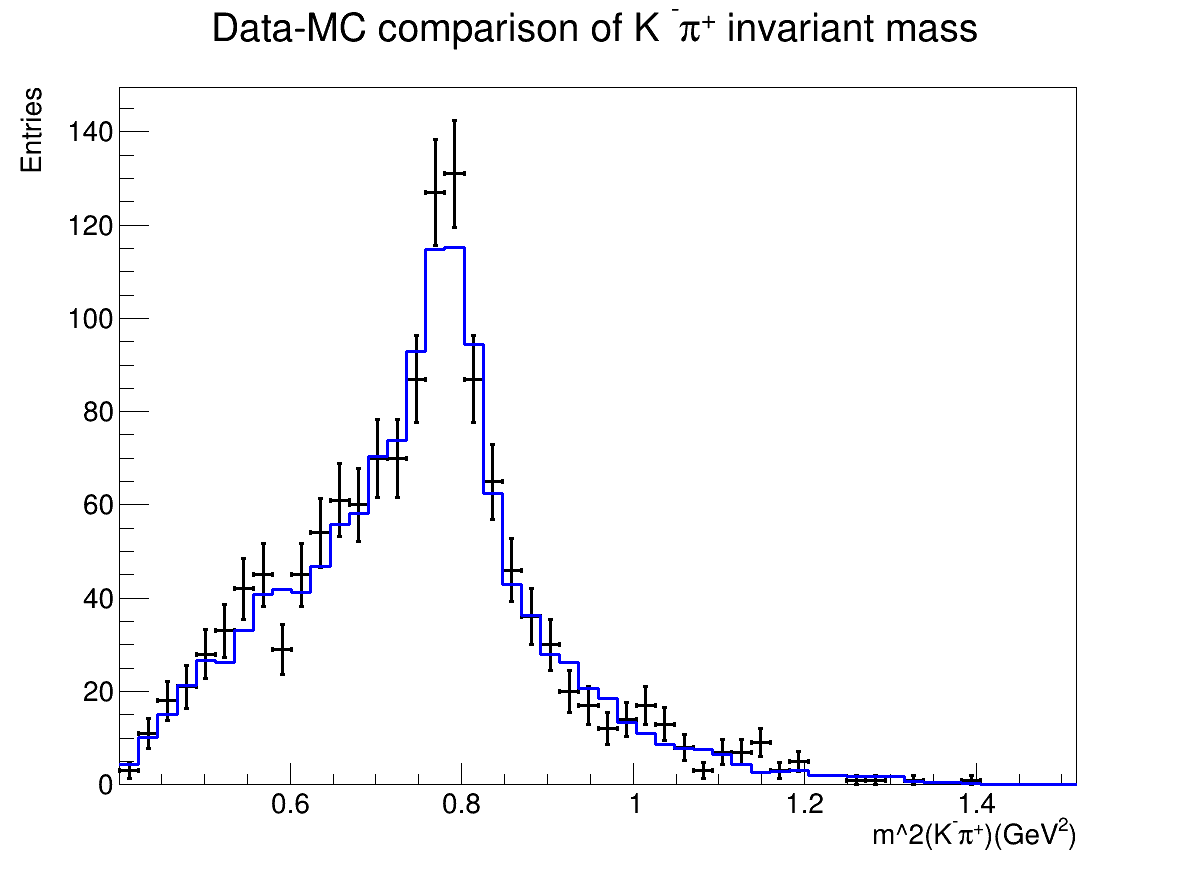

Info in <TCanvas::Print>: pdf file Data_MC_comparison_s12.pdf has been created


In [18]:
TCanvas s12_c("s12_c", "", 1200, 900);
s12_Data.Draw("E1");
s12_Data.SetTitle("Data-MC comparison of K^{-}#pi^{+} invariant mass;m^2(K^{-}#pi^{+})(GeV^{2});Entries");
s12_Data.SetLineColor(kBlack);
s12_Data.SetLineWidth(3);
s12_MC.Draw("HIST SAME");
s12_MC.SetLineColor(kBlue);
s12_MC.SetLineWidth(3);
s12_c.Draw();
s12_c.SaveAs("Data_MC_comparison_s12.pdf");

### $\pi^+\pi^-$ invariant mass histograms

In [19]:
TH1D s23_Data("s23_Data", "", 50, 0.27914078*0.27914078, 0.877486*0.877486);
TH1D s23_MC("s23_MC", "", 50, 0.27914078*0.27914078, 0.877486*0.877486);

In [20]:
std::string s23Formula = "(SignalPiPlusenergy + SignalPiMinusenergy)^2";
s23Formula += "- (SignalPiPluspx + SignalPiMinuspx)^2";
s23Formula += "- (SignalPiPluspy + SignalPiMinuspy)^2";
s23Formula += "- (SignalPiPluspz + SignalPiMinuspz)^2";

In [21]:
DataChain.Draw((s23Formula + " >> s23_Data").c_str(), CutFormula.c_str(), "GOFF");
MCChain.Draw((s23Formula + " >> s23_MC").c_str(), CutFormula.c_str(), "GOFF");
s23_MC.Scale(0.1);

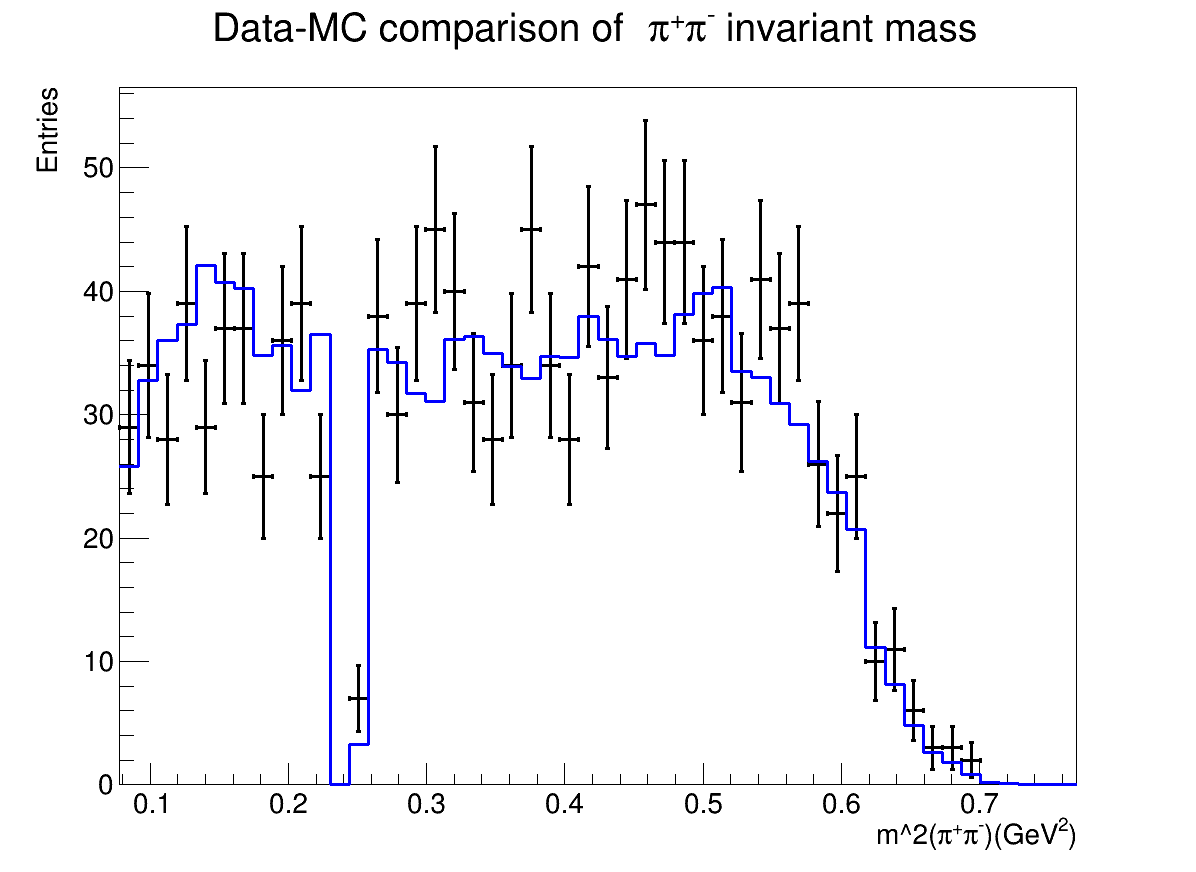

Info in <TCanvas::Print>: pdf file Data_MC_comparison_s23.pdf has been created


In [22]:
TCanvas s23_c("s23_c", "", 1200, 900);
s23_Data.Draw("E1");
s23_Data.SetTitle("Data-MC comparison of #pi^{+}#pi^{-} invariant mass;m^2(#pi^{+}#pi^{-})(GeV^{2});Entries");
s23_Data.SetLineColor(kBlack);
s23_Data.SetLineWidth(3);
s23_MC.Draw("HIST SAME");
s23_MC.SetLineColor(kBlue);
s23_MC.SetLineWidth(3);
s23_c.Draw();
s23_c.SaveAs("Data_MC_comparison_s23.pdf");

### $K^+K^-\pi^+$ invariant mass histograms

In [23]:
TH1D s012_Data("s012_Data", "", 50, 1.12692439*1.12692439, 1.72526961*1.72526961);
TH1D s012_MC("s012_MC", "", 50, 1.12692439*1.12692439, 1.72526961*1.72526961);

In [24]:
std::string s012Formula = "(SignalKPlusenergy + SignalKMinusenergy + SignalPiPlusenergy)^2";
s012Formula += "- (SignalKPluspx + SignalKMinuspx + SignalPiPluspx)^2";
s012Formula += "- (SignalKPluspy + SignalKMinuspy + SignalPiPluspy)^2";
s012Formula += "- (SignalKPluspz + SignalKMinuspz + SignalPiPluspz)^2";

In [25]:
std::string s013Formula = "(SignalKPlusenergy + SignalKMinusenergy + SignalPiMinusenergy)^2";
s013Formula += "- (SignalKPluspx + SignalKMinuspx + SignalPiMinuspx)^2";
s013Formula += "- (SignalKPluspy + SignalKMinuspy + SignalPiMinuspy)^2";
s013Formula += "- (SignalKPluspz + SignalKMinuspz + SignalPiMinuspz)^2";

In [26]:
std::string s012Formula_flavour = "(" + s012Formula + ")*(TagKCharge == -1)";
s012Formula_flavour += " + (" + s013Formula + ")*(TagKCharge == +1)";

In [27]:
DataChain.Draw((s012Formula_flavour + " >> s012_Data").c_str(), CutFormula.c_str(), "GOFF");
MCChain.Draw((s012Formula_flavour + " >> s012_MC").c_str(), CutFormula.c_str(), "GOFF");
s012_MC.Scale(0.1);

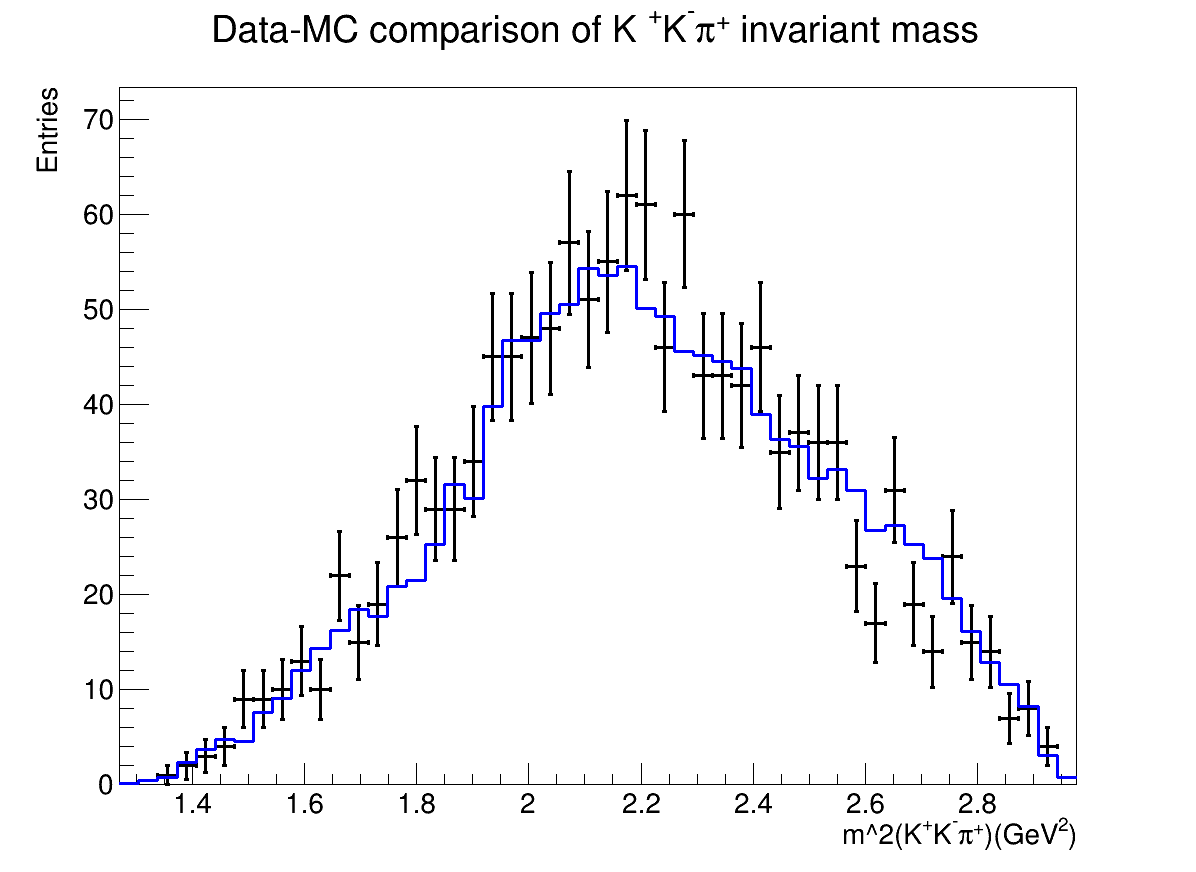

Info in <TCanvas::Print>: pdf file Data_MC_comparison_s012.pdf has been created


In [28]:
TCanvas s012_c("s012_c", "", 1200, 900);
s012_Data.Draw("E1");
s012_Data.SetTitle("Data-MC comparison of K^{+}K^{-}#pi^{+} invariant mass;m^2(K^{+}K^{-}#pi^{+})(GeV^{2});Entries");
s012_Data.SetLineColor(kBlack);
s012_Data.SetLineWidth(3);
s012_MC.Draw("HIST SAME");
s012_MC.SetLineColor(kBlue);
s012_MC.SetLineWidth(3);
s012_c.Draw();
s012_c.SaveAs("Data_MC_comparison_s012.pdf");